In [1]:
from dotenv import load_dotenv
from IPython.display import Markdown

In [2]:
load_dotenv()

True

#### Define State

In [3]:
from collections.abc import Sequence
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage, BaseMessage

TypedDict
- helps us define the schema of the state that flows throught the graph
- define dictionaries with explictly declared keys
- flag error for unexpected keys

all nodes of the graph will expect a fixed schema of the state

In [4]:
class State(TypedDict): # inherit from TypedDict Class
    messages: Sequence[BaseMessage]

In [5]:
state = State(messages = [HumanMessage("Tell me about a wormhole.")])

In [6]:
state

{'messages': [HumanMessage(content='Tell me about a wormhole.', additional_kwargs={}, response_metadata={})]}

#### Define Nodes

In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

In [8]:
chat = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite-preview",
    temperature = 0.6,
    max_output_tokens = 100,
    seed = 0
)

In [9]:
def chatbot(state: State) -> State:
    print("Entering Chatbot...")

    response = chat.invoke(state["messages"])
    display(Markdown(StrOutputParser().invoke(response)))

    return State(messages = [response])

In [10]:
chatbot(state)

Entering Chatbot...


A wormhole, known in physics as an **Einstein-Rosen bridge**, is a hypothetical "shortcut" through the fabric of spacetime. 

To visualize it, imagine spacetime as a two-dimensional sheet of paper. If you want to get from one corner to the opposite corner, you have to travel across the entire surface. However, if you fold the paper so the corners touch and poke a hole through them, you have created a shortcut. That hole is a wormhole

{'messages': [AIMessage(content=[{'type': 'text', 'text': 'A wormhole, known in physics as an **Einstein-Rosen bridge**, is a hypothetical "shortcut" through the fabric of spacetime. \n\nTo visualize it, imagine spacetime as a two-dimensional sheet of paper. If you want to get from one corner to the opposite corner, you have to travel across the entire surface. However, if you fold the paper so the corners touch and poke a hole through them, you have created a shortcut. That hole is a wormhole', 'extras': {'signature': 'EjQKMgEMOdbHc1kNOz/JOviYUdfLHcKbDvmsI1RAGGz41V1HrFZhI4Q5ANQodfjwFONIpWdI'}}], additional_kwargs={}, response_metadata={'finish_reason': 'MAX_TOKENS', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb71d-bd21-7581-aa3d-6de10dcd4258-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 96, 'total_tokens': 104, 'input_token_details': {'cache_read': 0}})]}

#### Define Graph

StateGraph: a graph whose nodes communicate by reading and writing to a shared node

In [11]:
from langgraph.graph import START, END, StateGraph

In [12]:
graph = StateGraph(State)

In [13]:
graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [14]:
graph = graph.compile() # performs checks to ensure graph is connected correctly and converts StateGraph into a runnable

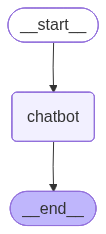

In [15]:
graph

#### Test the graph

In [16]:
graph.invoke(state)

Entering Chatbot...


A wormhole, known in physics as an **Einstein-Rosen bridge**, is a hypothetical "shortcut" through the fabric of spacetime. 

To visualize it, imagine spacetime as a two-dimensional sheet of paper. If you want to get from one corner to the opposite corner, you have to travel across the entire surface. However, if you fold the paper so the corners touch and poke a hole through them, you have created a shortcut. That hole is a wormhole

{'messages': [AIMessage(content=[{'type': 'text', 'text': 'A wormhole, known in physics as an **Einstein-Rosen bridge**, is a hypothetical "shortcut" through the fabric of spacetime. \n\nTo visualize it, imagine spacetime as a two-dimensional sheet of paper. If you want to get from one corner to the opposite corner, you have to travel across the entire surface. However, if you fold the paper so the corners touch and poke a hole through them, you have created a shortcut. That hole is a wormhole', 'extras': {'signature': 'EjQKMgEMOdbHqQ4vKb6YoJoWSrjKcsZ/RRvFgUWV/o6wvF9yFTrpvt4haNXmu3nPp48145A2'}}], additional_kwargs={}, response_metadata={'finish_reason': 'MAX_TOKENS', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb71d-cd67-7f10-a82f-419f94c4e713-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 96, 'total_tokens': 104, 'input_token_details': {'cache_read': 0}})]}